## AMES HOUSING DATASET ##

El siguiente dataset esta pensado para realizar modelos de regresion

79 variables explicativas 
El objetivo y target es el precio de venta

In [10]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Carga de datos
dataset = pd.read_csv('train.csv')
dataset.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


C:\Users\aaran\AppData\Local\Temp\ipykernel_23120\1137045867.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


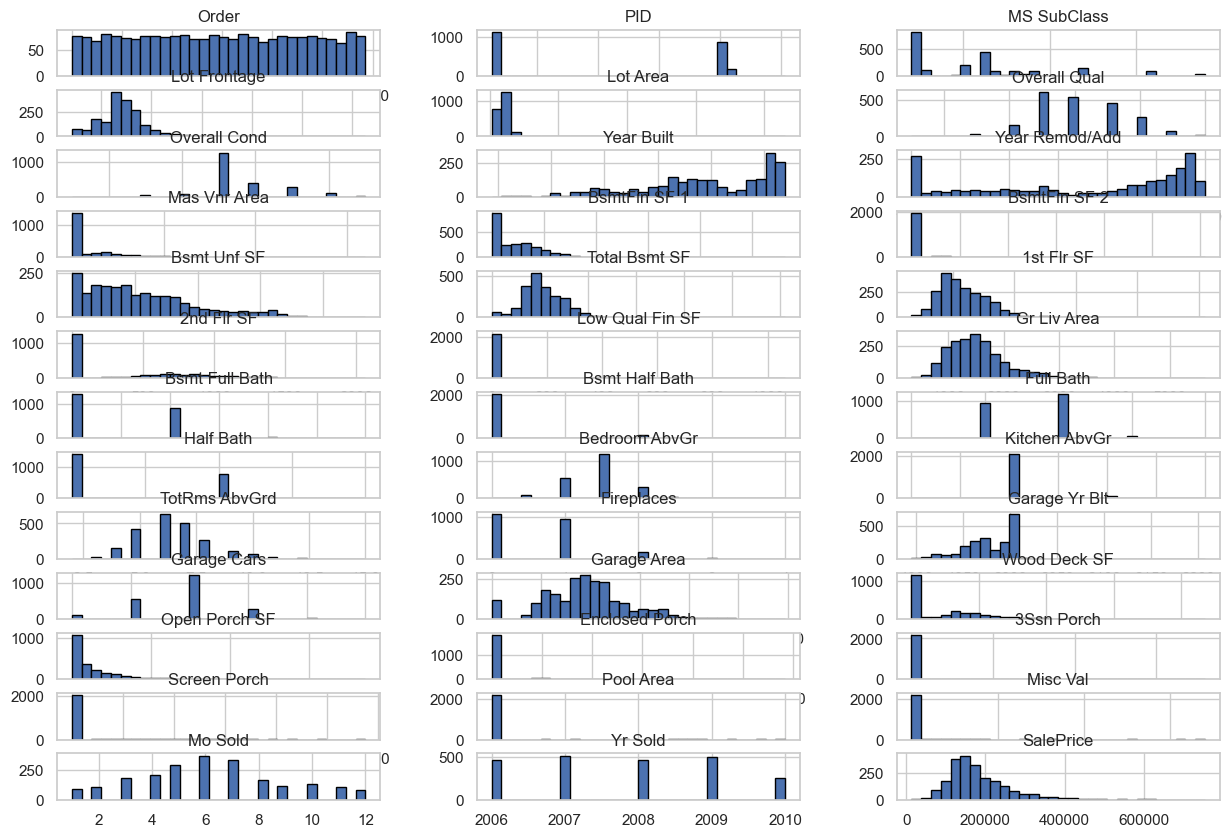

In [12]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

# Supongamos que tu dataframe se llama 'df'
# Creamos una cuadrícula de histogramas para todas las columnas numéricas
dataset.hist(bins=30, figsize=(15, 10), layout=(-1, 3), edgecolor='black')
plt.tight_layout()
plt.show()

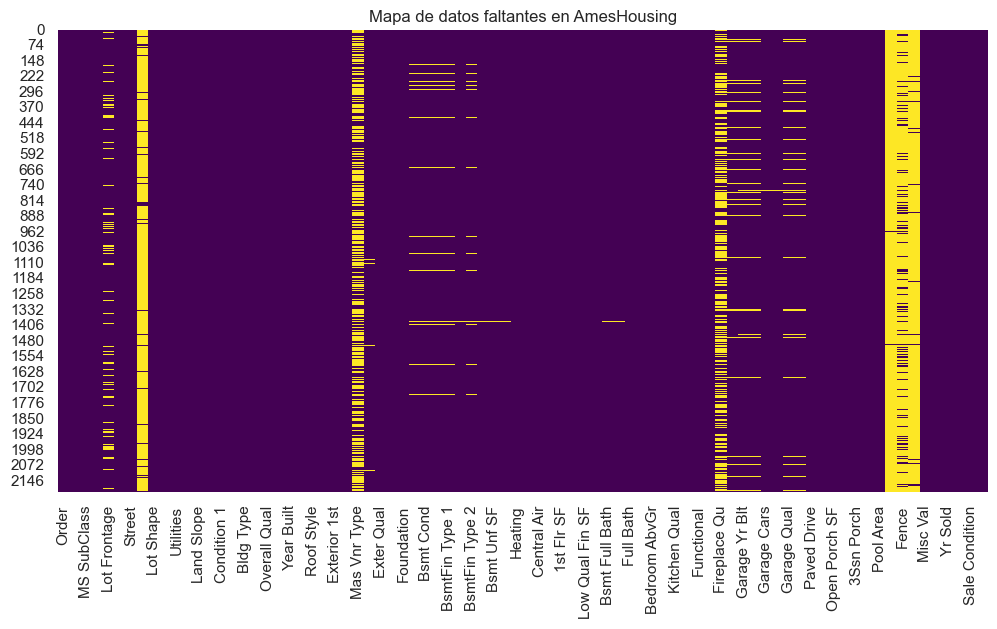

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(dataset.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de datos faltantes en AmesHousing")
plt.show()

In [14]:
print("Tamaño original:", dataset.shape)

# Eliminar filas con cualquier valor faltante
df_drop = dataset.dropna()

print("Tamaño después de dropna:", df_drop.shape)

# Comparar reducción
print("Filas eliminadas:", dataset.shape[0] - df_drop.shape[0])

Tamaño original: (2197, 82)
Tamaño después de dropna: (0, 82)
Filas eliminadas: 2197


In [46]:
dataset_fixed = dataset.copy()

In [47]:
#Estas columnas tienen una gran cantidad de valores faltantes, solo mostre una columna con estos datos eliminados para luego
#hacer algo con ellos, como eliminar la columna o rellenar los valores faltantes con una estrategia adecuada.
dataset_fixed = dataset_fixed.drop("Alley", axis=1)
dataset_fixed = dataset_fixed.drop("Pool QC", axis=1)
dataset_fixed = dataset_fixed.drop("Fence", axis=1)
dataset_fixed = dataset_fixed.drop("Misc Feature", axis=1)

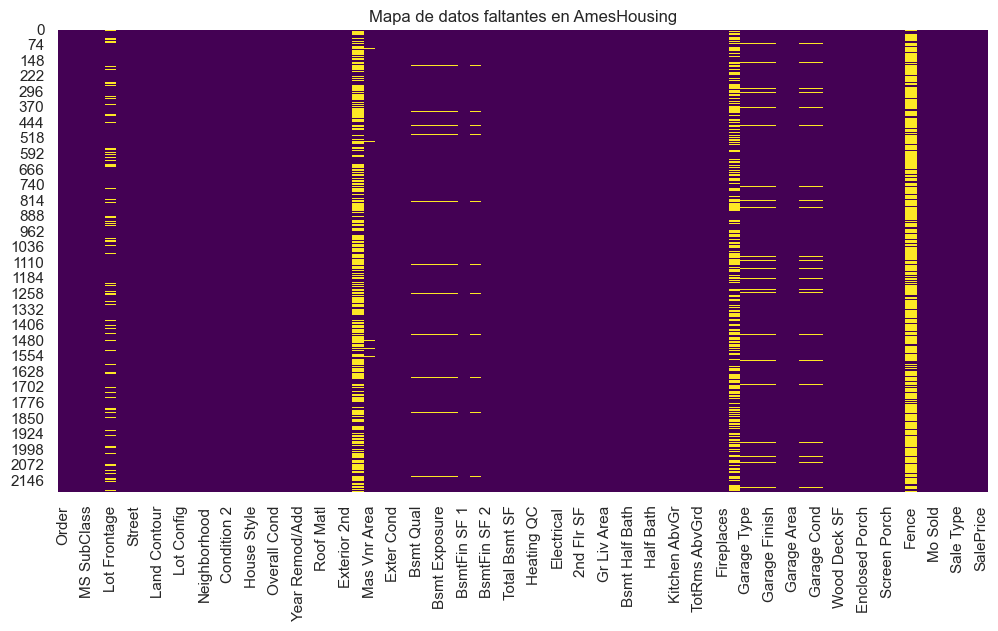

In [45]:
plt.figure(figsize=(12,6))
sns.heatmap(dataset_fixed.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de datos faltantes en AmesHousing")
plt.show()

In [49]:
# Conteo de valores faltantes por columna
faltantes = dataset.isna().sum()
print(faltantes[faltantes > 0])

Lot Frontage       362
Alley             2054
Mas Vnr Type      1329
Mas Vnr Area        22
Bsmt Qual           67
Bsmt Cond           67
Bsmt Exposure       69
BsmtFin Type 1      67
BsmtFin SF 1         1
BsmtFin Type 2      68
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       1
Bsmt Half Bath       1
Fireplace Qu      1066
Garage Type        120
Garage Yr Blt      122
Garage Finish      122
Garage Cars          1
Garage Area          1
Garage Qual        122
Garage Cond        122
Pool QC           2185
Fence             1778
Misc Feature      2117
dtype: int64


In [50]:
categorical_cols = dataset.select_dtypes(include=["object"]).columns
numeric_cols = dataset.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", len(categorical_cols))
print("Numéricas:", len(numeric_cols))

Categóricas: 43
Numéricas: 39


C:\Users\aaran\AppData\Local\Temp\ipykernel_23120\2302949936.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include=["object"]).columns


In [51]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

dataset[numeric_cols] = num_imputer.fit_transform(dataset[numeric_cols])
dataset[categorical_cols] = cat_imputer.fit_transform(dataset[categorical_cols])

In [54]:
from sklearn.preprocessing import OneHotEncoder

# En scikit-learn >= 1.2
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(dataset[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=dataset.index
)

dataset_final = pd.concat([dataset[numeric_cols], encoded_df, dataset["SalePrice"]], axis=1)

In [55]:
dataset_final.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial,SalePrice
0,534.0,531363010.0,20.0,80.0,9605.0,7.0,6.0,2007.0,2007.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,159000.0
1,803.0,906203120.0,20.0,90.0,14684.0,7.0,7.0,1990.0,1991.0,234.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,271900.0
2,956.0,916176030.0,20.0,69.0,14375.0,6.0,6.0,1958.0,1958.0,541.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,137500.0
3,460.0,528180130.0,120.0,48.0,6472.0,9.0,5.0,2008.0,2008.0,500.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,248500.0
4,487.0,528290030.0,80.0,61.0,9734.0,7.0,5.0,2004.0,2004.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,167000.0


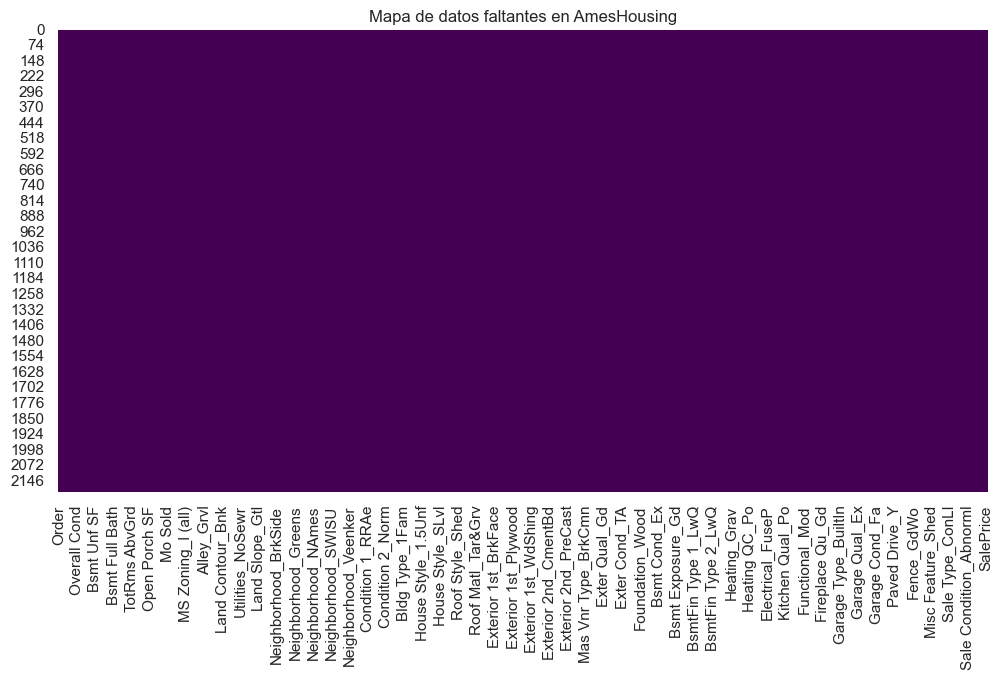

In [56]:
plt.figure(figsize=(12,6))
sns.heatmap(dataset_final.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de datos faltantes en AmesHousing")
plt.show()